<a href="https://colab.research.google.com/github/MaRiBlou/Maritime-Optimization/blob/main/notebooks/JIT_Arrival_and_Fuel_Consumption_for_Ships.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chunk Loader & Cleaner


In [3]:
import pandas as pd
import os
import urllib.request
import zipfile
from google.colab import drive

# 1. Σύνδεση με το Google Drive
drive.mount('/content/drive')

# 2. Ορισμός του χρονικού εύρους
# start_date = '2025-02-27'
# end_date = '2025-03-15'

# start_date = '2025-03-16'
# end_date = '2025-05-31'

# start_date = '2025-08-15'
# end_date = '2025-09-15'

start_date = '2025-12-15'
end_date = '2026-01-15'

# Δημιουργία λίστας με όλες τις ημερομηνίες ενδιάμεσα
date_list = pd.date_range(start=start_date, end=end_date).strftime('%Y-%m-%d')

# Διαδρομές (Paths)
base_url = "http://aisdata.ais.dk/aisdk-"
output_dir = '/content/drive/MyDrive/MSC_AIVC/DEEP_LEARNING/AIS_Daily_Data/'
os.makedirs(output_dir, exist_ok=True)

print(f"Θα πραγματοποιηθεί επεξεργασία για {len(date_list)} ημέρες.")

# 3. Ο κύριος βρόχος (Loop) αυτοματοποίησης
for date_str in date_list:
    zip_filename = f"aisdk-{date_str}.zip"
    csv_filename = f"aisdk-{date_str}.csv"
    url = f"{base_url}{date_str}.zip"

    print("\n" + "="*50)
    print(f"  ΕΝΑΡΞΗ ΕΠΕΞΕΡΓΑΣΙΑΣ ΓΙΑ ΤΗΝ ΗΜΕΡΑ: {date_str}")
    print("="*50)

    # Α. Λήψη (Download) αρχείου
    try:
        print(f"1. Λήψη αρχείου από το DMA...")
        urllib.request.urlretrieve(url, zip_filename)
    except Exception as e:
        print(f"❌ Αποτυχία λήψης για την ημερομηνία {date_str} (Ίσως δεν υπάρχει το αρχείο): {e}")
        continue

    # Β. Αποσυμπίεση (Unzip)
    print("2. Αποσυμπίεση αρχείων...")
    try:
        with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
            zip_ref.extractall('/content/')
    except Exception as e:
        print(f"❌ Σφάλμα κατά την αποσυμπίεση: {e}")
        if os.path.exists(zip_filename): os.remove(zip_filename)
        continue

    # Γ. Επεξεργασία με πακέτα (Chunking & Cleaning)
    temp_file_path = f"/content/{csv_filename}"
    if not os.path.exists(temp_file_path):
        print(f"❌ Το αρχείο {temp_file_path} δεν βρέθηκε μετά το unzip.")
        if os.path.exists(zip_filename): os.remove(zip_filename)
        continue

    print(f"3. Φιλτράρισμα & Downsampling (1 στίγμα/ώρα)")
    clean_chunks = []

    try:
        # Διαβάζουμε το αρχείο ανά 100.000 γραμμές
        chunk_iter = pd.read_csv(temp_file_path, chunksize=100000, low_memory=False)

        for chunk in chunk_iter:
            # Φιλτράρισμα τύπου πλοίου
            if 'Ship type' in chunk.columns:
                chunk = chunk[chunk['Ship type'].astype(str).str.contains('Cargo|Container|7', case=False, na=False)]

            # Καθαρισμός Null τιμών
            chunk = chunk.dropna(subset=['# Timestamp', 'MMSI', 'Latitude', 'Longitude', 'Heading', 'SOG'])

            # Μετατροπή Timestamp
            chunk['# Timestamp'] = pd.to_datetime(chunk['# Timestamp'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
            chunk = chunk.dropna(subset=['# Timestamp'])

            # Downsampling στο επίπεδο του chunk
            chunk['Hour_Floor'] = chunk['# Timestamp'].dt.floor('h')
            chunk_clean = chunk.drop_duplicates(subset=['MMSI', 'Hour_Floor'], keep='first')

            clean_chunks.append(chunk_clean)

        if clean_chunks:
            # Ένωση και τελικό drop duplicates στα όρια των chunks
            final_df = pd.concat(clean_chunks, ignore_index=True)
            final_df = final_df.drop_duplicates(subset=['MMSI', 'Hour_Floor'], keep='first')
            final_df = final_df.drop(columns=['Hour_Floor'])

            # Δ. Αποθήκευση στο Google Drive
            output_path = os.path.join(output_dir, f"Cleaned_AIS_{date_str}.csv")
            final_df.to_csv(output_path, index=False)
            print(f"✅ Επιτυχής αποθήκευση στο Drive: Cleaned_AIS_{date_str}.csv ({len(final_df)} εγγραφές).")
        else:
            print("⚠️ Δεν βρέθηκαν δεδομένα που να πληρούν τα κριτήρια φιλτραρίσματος.")

    except Exception as e:
        print(f"❌ Σφάλμα κατά την επεξεργασία του CSV: {e}")

    # Ε. ΚΡΙΣΙΜΟ ΒΗΜΑ: Καθαρισμός τοπικού δίσκου Colab
    print("4. Διαγραφή προσωρινών αρχείων από το Colab για εξοικονόμηση χώρου...")
    if os.path.exists(zip_filename): os.remove(zip_filename)
    if os.path.exists(temp_file_path): os.remove(temp_file_path)

print("\nΟΛΕΣ ΟΙ ΗΜΕΡΕΣ ΥΠΟΒΛΗΘΗΚΑΝ ΣΕ ΕΠΕΞΕΡΓΑΣΙΑ ΕΠΙΤΥΧΩΣ")

Mounted at /content/drive
Θα πραγματοποιηθεί επεξεργασία για 32 ημέρες.

  ΕΝΑΡΞΗ ΕΠΕΞΕΡΓΑΣΙΑΣ ΓΙΑ ΤΗΝ ΗΜΕΡΑ: 2025-12-15
1. Λήψη αρχείου από το DMA...


KeyboardInterrupt: 

Copernicus Marine Data

In [2]:
!pip install copernicusmarine

import copernicusmarine

# Στοιχεία λογαριασμού
USERNAME = "aivc25010@uniwa.gr"
PASSWORD = "aivc25010@MM"

# Σύνδεση με τον server
copernicusmarine.login(username=USERNAME, password=PASSWORD)
print("Η σύνδεση στο Copernicus ήταν επιτυχής!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, bu

INFO - 2026-06-20T05:03:23Z - Credentials file stored in /root/.copernicusmarine/.copernicusmarine-credentials.
INFO:copernicusmarine:Credentials file stored in /root/.copernicusmarine/.copernicusmarine-credentials.


Η σύνδεση στο Copernicus ήταν επιτυχής!


Waves

In [1]:
import os
import pandas as pd
import copernicusmarine

# --- 1. Διαδρομές Φακέλων στο Drive ---
ais_dir = '/content/drive/MyDrive/MSC_AIVC/DEEP_LEARNING/AIS_Daily_Data/'
copernicus_dir = '/content/drive/MyDrive/MSC_AIVC/DEEP_LEARNING/Copernicus_Data/'
os.makedirs(copernicus_dir, exist_ok=True)

# --- 2. Εύρεση όλων των καθαρισμένων αρχείων AIS ---
# Βρίσκει τα αρχεία (π.χ. Cleaned_AIS_2025-02-27.csv) και τα ταξινομεί
ais_files = sorted([f for f in os.listdir(ais_dir) if f.startswith('Cleaned_AIS_') and f.endswith('.csv')])

print(f"Βρέθηκαν {len(ais_files)} καθαρισμένα αρχεία AIS. Ξεκινάει η δυναμική λήψη καιρού...\n")

# --- 3. Δυναμικός Βρόχος Λήψης ---
for file in ais_files:
    # Εξαγωγή ημερομηνίας από το όνομα του αρχείου
    date_str = file.replace('Cleaned_AIS_', '').replace('.csv', '')

    output_filename = f"waves_{date_str}.nc"
    output_path = os.path.join(copernicus_dir, output_filename)

    # Αν το έχουμε ήδη κατεβάσει, προχωράμε στην επόμενη μέρα
    if os.path.exists(output_path):
        print(f"⏩ Το αρχείο {output_filename} υπάρχει ήδη. Παράλειψη.")
        continue

    # --- ΥΠΟΛΟΓΙΣΜΟΣ ΔΥΝΑΜΙΚΟΥ BOUNDING BOX ---
    file_path = os.path.join(ais_dir, file)

    # Διαβάζουμε ΜΟΝΟ το Latitude και Longitude (για ταχύτητα και εξοικονόμηση μνήμης)
    df_coords = pd.read_csv(file_path, usecols=['Latitude', 'Longitude'])

    buffer = 0.5 # Περιθώριο μισής μοίρας (~30 ναυτικά μίλια) για ασφάλεια

    min_lat = df_coords['Latitude'].min() - buffer
    max_lat = df_coords['Latitude'].max() + buffer
    min_lon = df_coords['Longitude'].min() - buffer
    max_lon = df_coords['Longitude'].max() + buffer

    # Απελευθέρωση μνήμης
    del df_coords

    print("-" * 50)
    print(f"Ημερομηνία: {date_str}")
    print(f"Όρια: Lat[{min_lat:.2f}, {max_lat:.2f}], Lon[{min_lon:.2f}, {max_lon:.2f}]")

    # --- ΚΛΗΣΗ ΣΤΟ COPERNICUS API ---
    try:
        copernicusmarine.subset(
            dataset_id="cmems_mod_glo_wav_anfc_0.083deg_PT3H-i",  # Global Waves
            variables=["VHM0", "VMDR"],                           # Ύψος (m) και Κατεύθυνση (μοίρες)
            start_datetime=f"{date_str}T00:00:00",
            end_datetime=f"{date_str}T23:59:59",
            minimum_longitude=min_lon,
            maximum_longitude=max_lon,
            minimum_latitude=min_lat,
            maximum_latitude=max_lat,
            output_filename=output_filename,
            output_directory=copernicus_dir,
            force_download=True
        )
        print(f"✅ Επιτυχής λήψη: {output_filename}")
    except Exception as e:
        print(f"❌ Σφάλμα κατά τη λήψη της ημέρας {date_str}: {e}")

print("\n Όλες οι λήψεις καιρού ολοκληρώθηκαν!")

Βρέθηκαν 158 καθαρισμένα αρχεία AIS. Ξεκινάει η δυναμική λήψη καιρού...



WARNING - 2026-06-19T21:03:27Z - 'force_download' has been deprecated.


--------------------------------------------------
Ημερομηνία: 2025-02-27
Όρια: Lat[53.27, 59.39], Lon[2.96, 22.99]


INFO - 2026-06-19T21:03:31Z - Selected dataset version: "202411"
INFO:copernicusmarine:Selected dataset version: "202411"
INFO - 2026-06-19T21:03:31Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
INFO - 2026-06-19T21:03:37Z - Total size of the download: 561.11 KB.
INFO:copernicusmarine:Total size of the download: 561.11 KB.


✅ Επιτυχής λήψη: waves_2025-02-27.nc


...

✅ Επιτυχής λήψη: waves_2026-01-13.nc
--------------------------------------------------
Ημερομηνία: 2026-01-14
Όρια: Lat[53.07, 59.12], Lon[3.04, 17.10]


INFO - 2026-06-19T21:29:05Z - Selected dataset version: "202411"
INFO:copernicusmarine:Selected dataset version: "202411"
INFO - 2026-06-19T21:29:05Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
INFO - 2026-06-19T21:29:10Z - Total size of the download: 399.06 KB.
INFO:copernicusmarine:Total size of the download: 399.06 KB.
WARNING - 2026-06-19T21:29:10Z - 'force_download' has been deprecated.


✅ Επιτυχής λήψη: waves_2026-01-14.nc
--------------------------------------------------
Ημερομηνία: 2026-01-15
Όρια: Lat[51.49, 59.29], Lon[2.12, 17.13]


INFO - 2026-06-19T21:29:14Z - Selected dataset version: "202411"
INFO:copernicusmarine:Selected dataset version: "202411"
INFO - 2026-06-19T21:29:14Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
INFO - 2026-06-19T21:29:20Z - Total size of the download: 542.35 KB.
INFO:copernicusmarine:Total size of the download: 542.35 KB.


✅ Επιτυχής λήψη: waves_2026-01-15.nc

 Όλες οι λήψεις καιρού ολοκληρώθηκαν!


Currents & Wind

In [4]:
import os
import pandas as pd
import copernicusmarine

# --- 1. Διαδρομές Φακέλων ---
ais_dir = '/content/drive/MyDrive/MSC_AIVC/DEEP_LEARNING/AIS_Daily_Data/'
copernicus_dir = '/content/drive/MyDrive/MSC_AIVC/DEEP_LEARNING/Copernicus_Data/'

# Εύρεση όλων των καθαρισμένων αρχείων AIS
ais_files = sorted([f for f in os.listdir(ais_dir) if f.startswith('Cleaned_AIS_') and f.endswith('.csv')])

print(f"Σε αναμονή/εκτέλεση για λήψη Ρευμάτων και Ανέμου για {len(ais_files)} ημέρες...\n")

# --- 2. Δυναμικός Βρόχος Λήψης (Ρεύματα & Άνεμος) ---
for file in ais_files:
    date_str = file.replace('Cleaned_AIS_', '').replace('.csv', '')

    currents_filename = f"currents_{date_str}.nc"
    wind_filename = f"wind_{date_str}.nc"
    currents_path = os.path.join(copernicus_dir, currents_filename)
    wind_path = os.path.join(copernicus_dir, wind_filename)

    # Έλεγχος αν υπάρχουν ΗΔΗ και τα δύο αρχεία
    if os.path.exists(currents_path) and os.path.exists(wind_path):
        print(f"⏩ Η ημέρα {date_str} έχει ήδη Ρεύματα και Άνεμο. Παράλειψη.")
        continue

    # --- ΥΠΟΛΟΓΙΣΜΟΣ BOUNDING BOX ---
    file_path = os.path.join(ais_dir, file)
    df_coords = pd.read_csv(file_path, usecols=['Latitude', 'Longitude'])
    buffer = 0.5
    min_lat = df_coords['Latitude'].min() - buffer
    max_lat = df_coords['Latitude'].max() + buffer
    min_lon = df_coords['Longitude'].min() - buffer
    max_lon = df_coords['Longitude'].max() + buffer
    del df_coords

    print("-" * 50)
    print(f"Ημερομηνία: {date_str} | Λήψη επιπλέον δεδομένων...")

    # --- ΚΛΗΣΗ ΓΙΑ ΡΕΥΜΑΤΑ (Currents) ---
    if not os.path.exists(currents_path):
        try:
            copernicusmarine.subset(
                dataset_id="cmems_mod_glo_phy_anfc_0.083deg_PT1H-m",  # Physics Dataset
                variables=["uo", "vo"],                               # Eastward/Northward current
                start_datetime=f"{date_str}T00:00:00",
                end_datetime=f"{date_str}T23:59:59",
                minimum_longitude=min_lon,
                maximum_longitude=max_lon,
                minimum_latitude=min_lat,
                maximum_latitude=max_lat,
                output_filename=currents_filename,
                output_directory=copernicus_dir,
                force_download=True
            )
            print(f"✅ Επιτυχής λήψη Ρευμάτων: {currents_filename}")
        except Exception as e:
            print(f"❌ Σφάλμα στα Ρεύματα ({date_str}): {e}")

    # --- ΚΛΗΣΗ ΓΙΑ ΑΝΕΜΟ (Wind) ---
    if not os.path.exists(wind_path):
        try:
            copernicusmarine.subset(
                dataset_id="cmems_obs-wind_glo_phy_nrt_l4_0.125deg_PT1H", # NRT Wind Dataset
                variables=["eastward_wind", "northward_wind"],           # Συνιστώσες ανέμου
                start_datetime=f"{date_str}T00:00:00",
                end_datetime=f"{date_str}T23:59:59",
                minimum_longitude=min_lon,
                maximum_longitude=max_lon,
                minimum_latitude=min_lat,
                maximum_latitude=max_lat,
                output_filename=wind_filename,
                output_directory=copernicus_dir,
                force_download=True
            )
            print(f"✅ Επιτυχής λήψη Ανέμου: {wind_filename}")
        except Exception as e:
            print(f"❌ Σφάλμα στον Άνεμο ({date_str}): {e}")

print("\n🎉 Όλες οι λήψεις Ρευμάτων και Ανέμου ολοκληρώθηκαν!")

Σε αναμονή/εκτέλεση για λήψη Ρευμάτων και Ανέμου για 158 ημέρες...

⏩ Η ημέρα 2025-02-27 έχει ήδη Ρεύματα και Άνεμο. Παράλειψη.
⏩ Η ημέρα 2025-02-28 έχει ήδη Ρεύματα και Άνεμο. Παράλειψη.
⏩ Η ημέρα 2025-03-01 έχει ήδη Ρεύματα και Άνεμο. Παράλειψη.
⏩ Η ημέρα 2025-03-02 έχει ήδη Ρεύματα και Άνεμο. Παράλειψη.
⏩ Η ημέρα 2025-03-03 έχει ήδη Ρεύματα και Άνεμο. Παράλειψη.
⏩ Η ημέρα 2025-03-04 έχει ήδη Ρεύματα και Άνεμο. Παράλειψη.
⏩ Η ημέρα 2025-03-05 έχει ήδη Ρεύματα και Άνεμο. Παράλειψη.
⏩ Η ημέρα 2025-03-06 έχει ήδη Ρεύματα και Άνεμο. Παράλειψη.
⏩ Η ημέρα 2025-03-07 έχει ήδη Ρεύματα και Άνεμο. Παράλειψη.
⏩ Η ημέρα 2025-03-08 έχει ήδη Ρεύματα και Άνεμο. Παράλειψη.
⏩ Η ημέρα 2025-03-09 έχει ήδη Ρεύματα και Άνεμο. Παράλειψη.
⏩ Η ημέρα 2025-03-10 έχει ήδη Ρεύματα και Άνεμο. Παράλειψη.
⏩ Η ημέρα 2025-03-11 έχει ήδη Ρεύματα και Άνεμο. Παράλειψη.
⏩ Η ημέρα 2025-03-12 έχει ήδη Ρεύματα και Άνεμο. Παράλειψη.
⏩ Η ημέρα 2025-03-13 έχει ήδη Ρεύματα και Άνεμο. Παράλειψη.
⏩ Η ημέρα 2025-03-14 έχει ήδη Ρε

THETIS MRV - Annual data cleaning

In [4]:
import os
import pandas as pd
import glob
from google.colab import drive

# 1. Σύνδεση με το Google Drive
drive.mount('/content/drive')

# Καθορισμός διαδρομών
thetis_dir = '/content/drive/MyDrive/MSC_AIVC/DEEP_LEARNING/THETIS_MRV/'
thetis_files = glob.glob(os.path.join(thetis_dir, '*.xlsx'))

target_ships = ['Container ship', 'Container/ro-ro cargo ship']
clean_years_data = []


for file in thetis_files:
    print(f"Επεξεργασία: {os.path.basename(file)}")
    try:
        # Διαβάζουμε το Excel (Χρησιμοποιούμε header=2 γιατί οι τίτλοι είναι στην 3η γραμμή)
        df_temp = pd.read_excel(file, header=2)

        # Μετατροπή όλων των στηλών σε string για ασφάλεια
        cols = df_temp.columns.astype(str)

        # Ψάχνουμε λέξεις κλειδιά μέσα στα ονόματα των στηλών
        imo_col = next((c for c in cols if 'IMO Number' in c), None)
        ship_type_col = next((c for c in cols if 'Ship type' in c), None)
        fuel_col = next((c for c in cols if 'fuel consumption' in c.lower() and 'total' in c.lower()), None)
        co2_col = next((c for c in cols if 'co₂ emission' in c.lower() or 'co2 emission' in c.lower()), None)
        time_col = next((c for c in cols if 'time spent at sea' in c.lower()), None)

        # Αν λείπει κάποια από τις βασικές, προχωράμε στο επόμενο αρχείο
        if not all([imo_col, ship_type_col, fuel_col]):
            print("  ❌ Λείπει το IMO, το Ship type ή το Fuel Consumption. Παράλειψη.")
            continue

        # Κρατάμε μόνο τις στήλες που βρήκαμε
        columns_to_keep = [c for c in [imo_col, ship_type_col, fuel_col, co2_col, time_col] if c is not None]
        df_temp = df_temp[columns_to_keep]

        # Μετονομασία για το dataset μας
        rename_dict = {
            imo_col: 'IMO_Number',
            ship_type_col: 'Ship_Type',
            fuel_col: 'Total_Fuel_Consumption'
        }
        if co2_col: rename_dict[co2_col] = 'Total_CO2'
        if time_col: rename_dict[time_col] = 'Time_at_Sea_Hours'

        df_temp = df_temp.rename(columns=rename_dict)

        # ΦΙΛΤΡΑΡΙΣΜΑ ΚΑΙ ΚΑΘΑΡΙΣΜΟΣ
        # 1. Μόνο Container Ships
        df_temp = df_temp[df_temp['Ship_Type'].isin(target_ships)]

        # 2. Πετάμε όσα έχουν κενή κατανάλωση
        df_temp = df_temp.dropna(subset=['Total_Fuel_Consumption'])

        # Αποθηκεύουμε το έτος στη λίστα
        clean_years_data.append(df_temp)
        print(f"  ✅ Επιτυχία: Εξήχθησαν δεδομένα Καυσίμου & CO2 για {len(df_temp)} πλοία.")

    except Exception as e:
        print(f"  ❌ Σφάλμα: {e}")

# ΤΕΛΙΚΗ ΣΥΓΧΩΝΕΥΣΗ
if clean_years_data:
    df_master_mrv = pd.concat(clean_years_data, ignore_index=True)
    print(f"\n ΟΛΟΚΛΗΡΩΘΗΚΕ! Το πολυετές dataset περιέχει {len(df_master_mrv)} εγγραφές Container Ships.")

    # Αποθήκευση στο Drive
    output_path = '/content/drive/MyDrive/MSC_AIVC/DEEP_LEARNING/MASTER_THETIS_ContainerShips_MultiYear.csv'
    df_master_mrv.to_csv(output_path, index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Επεξεργασία: 2018-v275-29032026-EU MRV Publication of information.xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


  ✅ Επιτυχία: Εξήχθησαν δεδομένα Καυσίμου & CO2 για 1893 πλοία.
Επεξεργασία: 2019-v227-28052025-EU MRV Publication of information.xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


  ✅ Επιτυχία: Εξήχθησαν δεδομένα Καυσίμου & CO2 για 1928 πλοία.
Επεξεργασία: 2020-v208-04022026-EU MRV Publication of information.xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


  ✅ Επιτυχία: Εξήχθησαν δεδομένα Καυσίμου & CO2 για 1929 πλοία.
Επεξεργασία: 2021-v217-17032026-EU MRV Publication of information.xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


  ✅ Επιτυχία: Εξήχθησαν δεδομένα Καυσίμου & CO2 για 1923 πλοία.

 ΟΛΟΚΛΗΡΩΘΗΚΕ! Το πολυετές dataset περιέχει 7673 εγγραφές Container Ships.


Consumption per hour (Baseline)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Φόρτωση του Master THETIS
df_mrv = pd.read_csv('/content/drive/MyDrive/MSC_AIVC/DEEP_LEARNING/MASTER_THETIS_ContainerShips_MultiYear.csv')


# 1. Υπολογισμός Ωριαίας Κατανάλωσης
# Καύσιμα (Τόνοι) / Ώρες Εν Πλω
df_mrv['Fuel_per_Hour_Tonnes'] = df_mrv['Total_Fuel_Consumption'] / df_mrv['Time_at_Sea_Hours']

# 2. Καθαρισμός Ακραίων Τιμών (Outliers)
# Αφαιρούμε άπειρες τιμές (π.χ. αν κάποιος δήλωσε 0 ώρες από λάθος)
df_mrv.replace([np.inf, -np.inf], np.nan, inplace=True)
df_mrv = df_mrv.dropna(subset=['Fuel_per_Hour_Tonnes'])

# Φιλτράρουμε ρεαλιστικές τιμές (π.χ. αποκλείουμε τιμές > 50 τόνους/ώρα)
df_mrv = df_mrv[(df_mrv['Fuel_per_Hour_Tonnes'] > 0) & (df_mrv['Fuel_per_Hour_Tonnes'] < 50)]

print(f"Μετά τον καθαρισμό ακραίων τιμών: {len(df_mrv)} εγγραφές.")

# 3. Το Τελικό Baseline
baseline_fuel = df_mrv['Fuel_per_Hour_Tonnes'].mean()
median_fuel = df_mrv['Fuel_per_Hour_Tonnes'].median()

print("-" * 50)
print(f"ΒΑΣΙΚΟΣ ΜΕΣΟΣ ΟΡΟΣ (Baseline): {baseline_fuel:.2f} Τόνοι/Ώρα")
print(f"ΔΙΑΜΕΣΟΣ (Πιο ανθεκτική σε outliers): {median_fuel:.2f} Τόνοι/Ώρα")
print("-" * 50)

Μετά τον καθαρισμό ακραίων τιμών: 7476 εγγραφές.
--------------------------------------------------
ΒΑΣΙΚΟΣ ΜΕΣΟΣ ΟΡΟΣ (Baseline): 2.67 Τόνοι/Ώρα
ΔΙΑΜΕΣΟΣ (Πιο ανθεκτική σε outliers): 2.34 Τόνοι/Ώρα
--------------------------------------------------


Data Fusion

In [8]:
import os
import pandas as pd
import numpy as np
import xarray as xr
import warnings


# 1. ΒΟΗΘΗΤΙΚΕΣ ΣΥΝΑΡΤΗΣΕΙΣ
def calculate_magnitude_direction(u, v):
    """Μετατροπή u, v διανυσμάτων σε Ταχύτητα και Μοίρες (0-360)"""
    speed = np.sqrt(u**2 + v**2)
    direction = (np.degrees(np.arctan2(u, v))) % 360
    return speed, direction

# 2. ΡΥΘΜΙΣΕΙΣ ΦΑΚΕΛΩΝ

ais_dir = '/content/drive/MyDrive/MSC_AIVC/DEEP_LEARNING/AIS_Daily_Data/'
copernicus_dir = '/content/drive/MyDrive/MSC_AIVC/DEEP_LEARNING/Copernicus_Data/'
output_file = '/content/drive/MyDrive/MSC_AIVC/DEEP_LEARNING/FINAL_ML_DATASET.csv'

ais_files = sorted([f for f in os.listdir(ais_dir) if f.startswith('Cleaned_AIS_') and f.endswith('.csv')])
all_fused_data = []


# 3. ΒΡΟΧΟΣ ΕΠΕΞΕΡΓΑΣΙΑΣ ΑΝΑ ΗΜΕΡΑ
for file in ais_files:
    date_str = file.replace('Cleaned_AIS_', '').replace('.csv', '')

    waves_path = os.path.join(copernicus_dir, f'waves_{date_str}.nc')
    currents_path = os.path.join(copernicus_dir, f'currents_{date_str}.nc')
    wind_path = os.path.join(copernicus_dir, f'wind_{date_str}.nc')

    if not (os.path.exists(waves_path) and os.path.exists(currents_path) and os.path.exists(wind_path)):
        print(f"⚠️ Λείπουν αρχεία .nc για την {date_str}. Παράλειψη.")
        continue

    print(f"⏳ Επεξεργασία Ημέρας: {date_str}")

    try:
        # Φόρτωση AIS
        df_ais = pd.read_csv(os.path.join(ais_dir, file))

        # ΚΑΘΑΡΙΣΜΟΣ ΣΤΗΛΩΝ
        df_ais.columns = df_ais.columns.str.strip()
        if '# Timestamp' in df_ais.columns:
            df_ais.rename(columns={'# Timestamp': 'Timestamp'}, inplace=True)

        df_ais['Timestamp'] = pd.to_datetime(df_ais['Timestamp'])

        # Λύση για το Heading (Χρήση COG ως Fallback)
        if 'Heading' not in df_ais.columns:
            df_ais['Heading'] = df_ais['COG']
        else:
            df_ais['Heading'] = df_ais['Heading'].replace(511, np.nan)
            df_ais['Heading'] = df_ais['Heading'].fillna(df_ais['COG'])

        # Δημιουργία DataArrays για την παρεμβολή του xarray
        t_points = xr.DataArray(df_ais['Timestamp'], dims='points')
        lat_points = xr.DataArray(df_ais['Latitude'], dims='points')
        lon_points = xr.DataArray(df_ais['Longitude'], dims='points')

        # Φόρτωση των NetCDF
        ds_waves = xr.open_dataset(waves_path)
        ds_currents = xr.open_dataset(currents_path)
        ds_wind = xr.open_dataset(wind_path)

        # INTERPOLATION
        interp_waves = ds_waves.interp(time=t_points, latitude=lat_points, longitude=lon_points, method='nearest')
        interp_currents = ds_currents.interp(time=t_points, latitude=lat_points, longitude=lon_points, method='nearest')
        interp_wind = ds_wind.interp(time=t_points, latitude=lat_points, longitude=lon_points, method='nearest')

        # Πέρασμα των τιμών στο Pandas
        df_ais['Wave_Height_VHM0'] = interp_waves['VHM0'].values
        df_ais['Wave_Direction_VMDR'] = interp_waves['VMDR'].values
        df_ais['Current_Speed'], df_ais['Current_Dir'] = calculate_magnitude_direction(interp_currents['uo'].values, interp_currents['vo'].values)
        df_ais['Wind_Speed'], df_ais['Wind_Dir'] = calculate_magnitude_direction(interp_wind['eastward_wind'].values, interp_wind['northward_wind'].values)

        # Κλείσιμο αρχείων
        ds_waves.close(); ds_currents.close(); ds_wind.close()

        # Καθαρισμός τυχόν NaN τιμών
        df_ais.ffill(inplace=True)
        df_ais.bfill(inplace=True)


        # 4. ΜΗΧΑΝΙΚΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ & ΥΔΡΟΔΥΝΑΜΙΚΗ
        df_ais['Rel_Wave_Dir_cos'] = np.cos(np.radians((df_ais['Wave_Direction_VMDR'] - df_ais['Heading']) % 360))
        df_ais['Rel_Wave_Dir_sin'] = np.sin(np.radians((df_ais['Wave_Direction_VMDR'] - df_ais['Heading']) % 360))

        df_ais['Rel_Wind_Dir_cos'] = np.cos(np.radians((df_ais['Wind_Dir'] - df_ais['Heading']) % 360))
        df_ais['Rel_Wind_Dir_sin'] = np.sin(np.radians((df_ais['Wind_Dir'] - df_ais['Heading']) % 360))

        df_ais['Rel_Current_Dir_cos'] = np.cos(np.radians((df_ais['Current_Dir'] - df_ais['Heading']) % 360))

        # Υπολογισμός STW
        df_ais['STW'] = df_ais['SOG'] - (df_ais['Current_Speed'] * df_ais['Rel_Current_Dir_cos'])
        df_ais['STW'] = df_ais['STW'].clip(lower=0.1)

        # Βασική Κατανάλωση
        k_constant = 2.34 / (15 ** 3)
        base_fuel = k_constant * (df_ais['STW'] ** 3)

        # Ποινές Καιρού
        wind_penalty = 0.001 * (df_ais['Wind_Speed'] ** 2) * (1 - df_ais['Rel_Wind_Dir_cos'])
        wave_penalty = 0.05 * (df_ais['Wave_Height_VHM0'] ** 2) * (1 - df_ais['Rel_Wave_Dir_cos'])

        ideal_fuel = base_fuel + wind_penalty + wave_penalty

        # Θόρυβος & CO2
        np.random.seed(42)
        sigma = 0.05 * ideal_fuel
        gaussian_noise = np.random.normal(loc=0, scale=sigma)

        df_ais['Fuel_Consumption_Target'] = (ideal_fuel + gaussian_noise).clip(lower=0.2)
        df_ais['CO2_Emissions_Target'] = df_ais['Fuel_Consumption_Target'] * 3.179

        # Επιλογή Στηλών ML
        ml_columns = [
            'Timestamp', 'SOG', 'STW', 'Heading', 'Wave_Height_VHM0', 'Wind_Speed', 'Current_Speed',
            'Rel_Wave_Dir_cos', 'Rel_Wave_Dir_sin', 'Rel_Wind_Dir_cos', 'Rel_Wind_Dir_sin',
            'Fuel_Consumption_Target', 'CO2_Emissions_Target'
        ]

        all_fused_data.append(df_ais[ml_columns])

    except Exception as e:
        print(f"❌ Σφάλμα στην επεξεργασία της ημέρας {date_str}: {e}")


# 5. ΤΕΛΙΚΗ ΣΥΓΧΩΝΕΥΣΗ (MASTER ML DATASET)
if all_fused_data:
    df_final = pd.concat(all_fused_data, ignore_index=True)
    df_final.to_csv(output_file, index=False)
    print(f"\n🎉 ΕΠΙΤΥΧΙΑ! Το Τελικό ML Dataset δημιουργήθηκε με {len(df_final)} εγγραφές.")
    print(f"💾 Αποθηκεύτηκε στο: {output_file}")
else:
    print("\n⚠️ Δεν ενώθηκαν δεδομένα. Ελέγξτε τις διαδρομές των αρχείων.")

⏳ Επεξεργασία Ημέρας: 2025-02-27
⏳ Επεξεργασία Ημέρας: 2025-02-28
⏳ Επεξεργασία Ημέρας: 2025-03-01
⏳ Επεξεργασία Ημέρας: 2025-03-02
⏳ Επεξεργασία Ημέρας: 2025-03-03
⏳ Επεξεργασία Ημέρας: 2025-03-04
⏳ Επεξεργασία Ημέρας: 2025-03-05
⏳ Επεξεργασία Ημέρας: 2025-03-06
⏳ Επεξεργασία Ημέρας: 2025-03-07
⏳ Επεξεργασία Ημέρας: 2025-03-08
⏳ Επεξεργασία Ημέρας: 2025-03-09
⏳ Επεξεργασία Ημέρας: 2025-03-10
⏳ Επεξεργασία Ημέρας: 2025-03-11
⏳ Επεξεργασία Ημέρας: 2025-03-12
⏳ Επεξεργασία Ημέρας: 2025-03-13
⏳ Επεξεργασία Ημέρας: 2025-03-14
⏳ Επεξεργασία Ημέρας: 2025-03-15
⏳ Επεξεργασία Ημέρας: 2025-03-16
⏳ Επεξεργασία Ημέρας: 2025-03-17
⏳ Επεξεργασία Ημέρας: 2025-03-18
⏳ Επεξεργασία Ημέρας: 2025-03-19
⏳ Επεξεργασία Ημέρας: 2025-03-20
⏳ Επεξεργασία Ημέρας: 2025-03-21
⏳ Επεξεργασία Ημέρας: 2025-03-22
⏳ Επεξεργασία Ημέρας: 2025-03-23
⏳ Επεξεργασία Ημέρας: 2025-03-24
⏳ Επεξεργασία Ημέρας: 2025-03-25
⏳ Επεξεργασία Ημέρας: 2025-03-26
⏳ Επεξεργασία Ημέρας: 2025-03-27
⏳ Επεξεργασία Ημέρας: 2025-03-28
⏳ Επεξεργα

Outlier Filtering - Feature Extraction - Data split (70-20-10)


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# 1. Σύνδεση με το Google Drive
drive.mount('/content/drive')

# ΦΟΡΤΩΣΗ ΤΟΥ DATASET
df_fused = pd.read_csv('/content/drive/MyDrive/MSC_AIVC/DEEP_LEARNING/FINAL_ML_DATASET.csv')

print(f"Αρχικό μέγεθος: {len(df_fused)} γραμμές")

# 1. Φιλτράρισμα ταχυτήτων - Κρατάμε μόνο πλοία που κινούνται με ρεαλιστικές ταχύτητες (π.χ. 2 έως 25 κόμβους)
df_fused = df_fused[(df_fused['SOG'] >= 2) & (df_fused['SOG'] <= 25)]

# 2. Φιλτράρισμα ακραίων τιμών (outliers) στον συνθετικό στόχο
# Διαγράφουμε τα 'glitches' που προκάλεσαν καταναλώσεις > 40 τόνους/ώρα λόγω σφαλμάτων του AIS
df_fused = df_fused[df_fused['Fuel_Consumption_Target'] <= 40]

print(f"Μέγεθος μετά τον καθαρισμό των Outliers: {len(df_fused)} γραμμές")

# ΟΡΙΣΜΟΣ FEATURES (X) ΚΑΙ TARGET (y)
# Επιλέγουμε τα χαρακτηριστικά (Features)
X = df_fused[[
    'SOG', 'STW', 'Wave_Height_VHM0', 'Wind_Speed', 'Current_Speed',
    'Rel_Wave_Dir_cos', 'Rel_Wave_Dir_sin', 'Rel_Wind_Dir_cos', 'Rel_Wind_Dir_sin'
]]
y = df_fused['Fuel_Consumption_Target']

# 1ο Βήμα: Κόβουμε το πρώτο 70% για Train και κρατάμε το υπόλοιπο 30% ως προσωρινό
# Το shuffle=False εξασφαλίζει ότι τα δεδομένα μένουν στη σωστή χρονική σειρά
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, shuffle=False)

# 2ο Βήμα: Από το προσωρινό 30%, κόβουμε το 2/3 για Validation και το 1/3 για Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.3333, shuffle=False)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


print(f"Δεδομένα Εκπαίδευσης (Train - 70%): {X_train.shape[0]} γραμμές")
print(f"Δεδομένα Επικύρωσης (Validation - 20%): {X_val.shape[0]} γραμμές")
print(f"Δεδομένα Ελέγχου (Test - 10%): {X_test.shape[0]} γραμμές")



Mounted at /content/drive
Αρχικό μέγεθος: 1428742 γραμμές
Μέγεθος μετά τον καθαρισμό των Outliers: 844485 γραμμές
Δεδομένα Εκπαίδευσης (Train - 70%): 591139 γραμμές
Δεδομένα Επικύρωσης (Validation - 20%): 168905 γραμμές
Δεδομένα Ελέγχου (Test - 10%): 84441 γραμμές


Εκπαίδευση LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.055601 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2257
[LightGBM] [Info] Number of data points in the train set: 591139, number of used features: 9
[LightGBM] [Info] Start training from score 1.181893
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Εκπαίδευση Hist-Gradient Boosting...
 Εκπαίδευση BPNN (MLP)...
Εκπαίδευση Voting-BRL...
Εκπαίδευση LSTM...

Πίνακας Συνολικών Αποτελεσμάτων:


,Model,R2,RMSE,MAE,Time (s)
0,LightGBM,0.9918,0.0878,0.0529,23.5499
1,Hist-GB,0.9867,0.1116,0.0652,7.4395
2,BPNN,0.9906,0.0938,0.0602,33.6275
3,Voting-BRL,0.8125,0.4189,0.2667,5.7780
4,LSTM,0.9932,0.0798,0.0499,407.4295


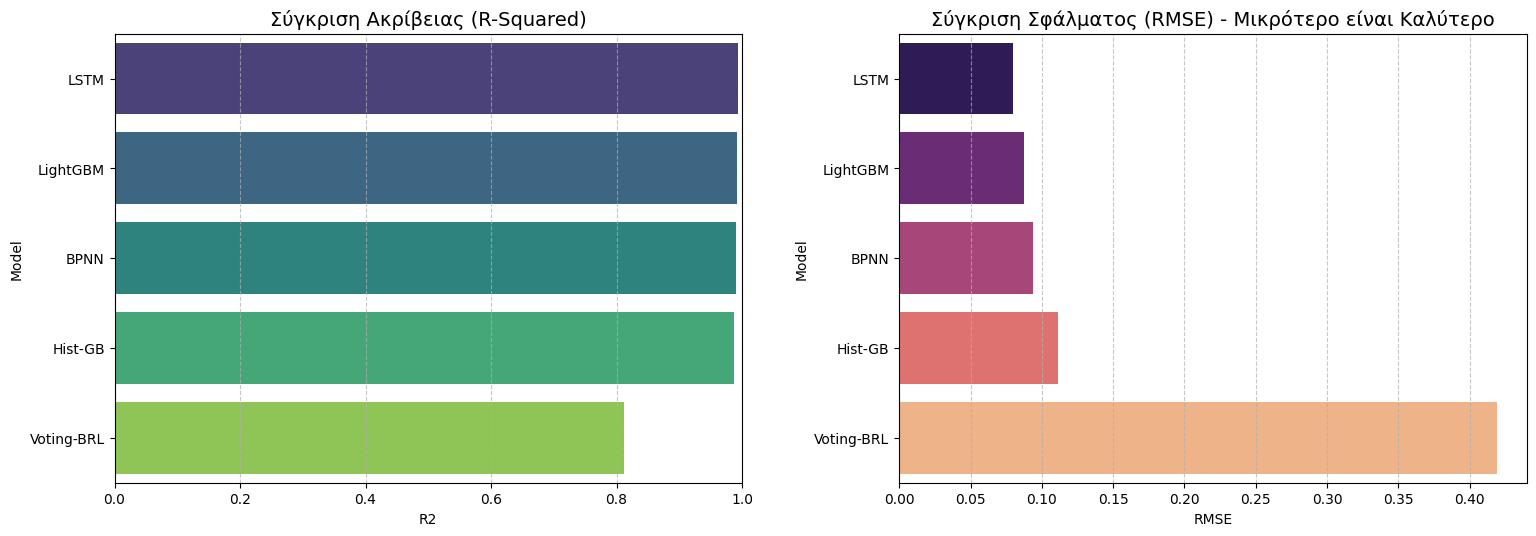

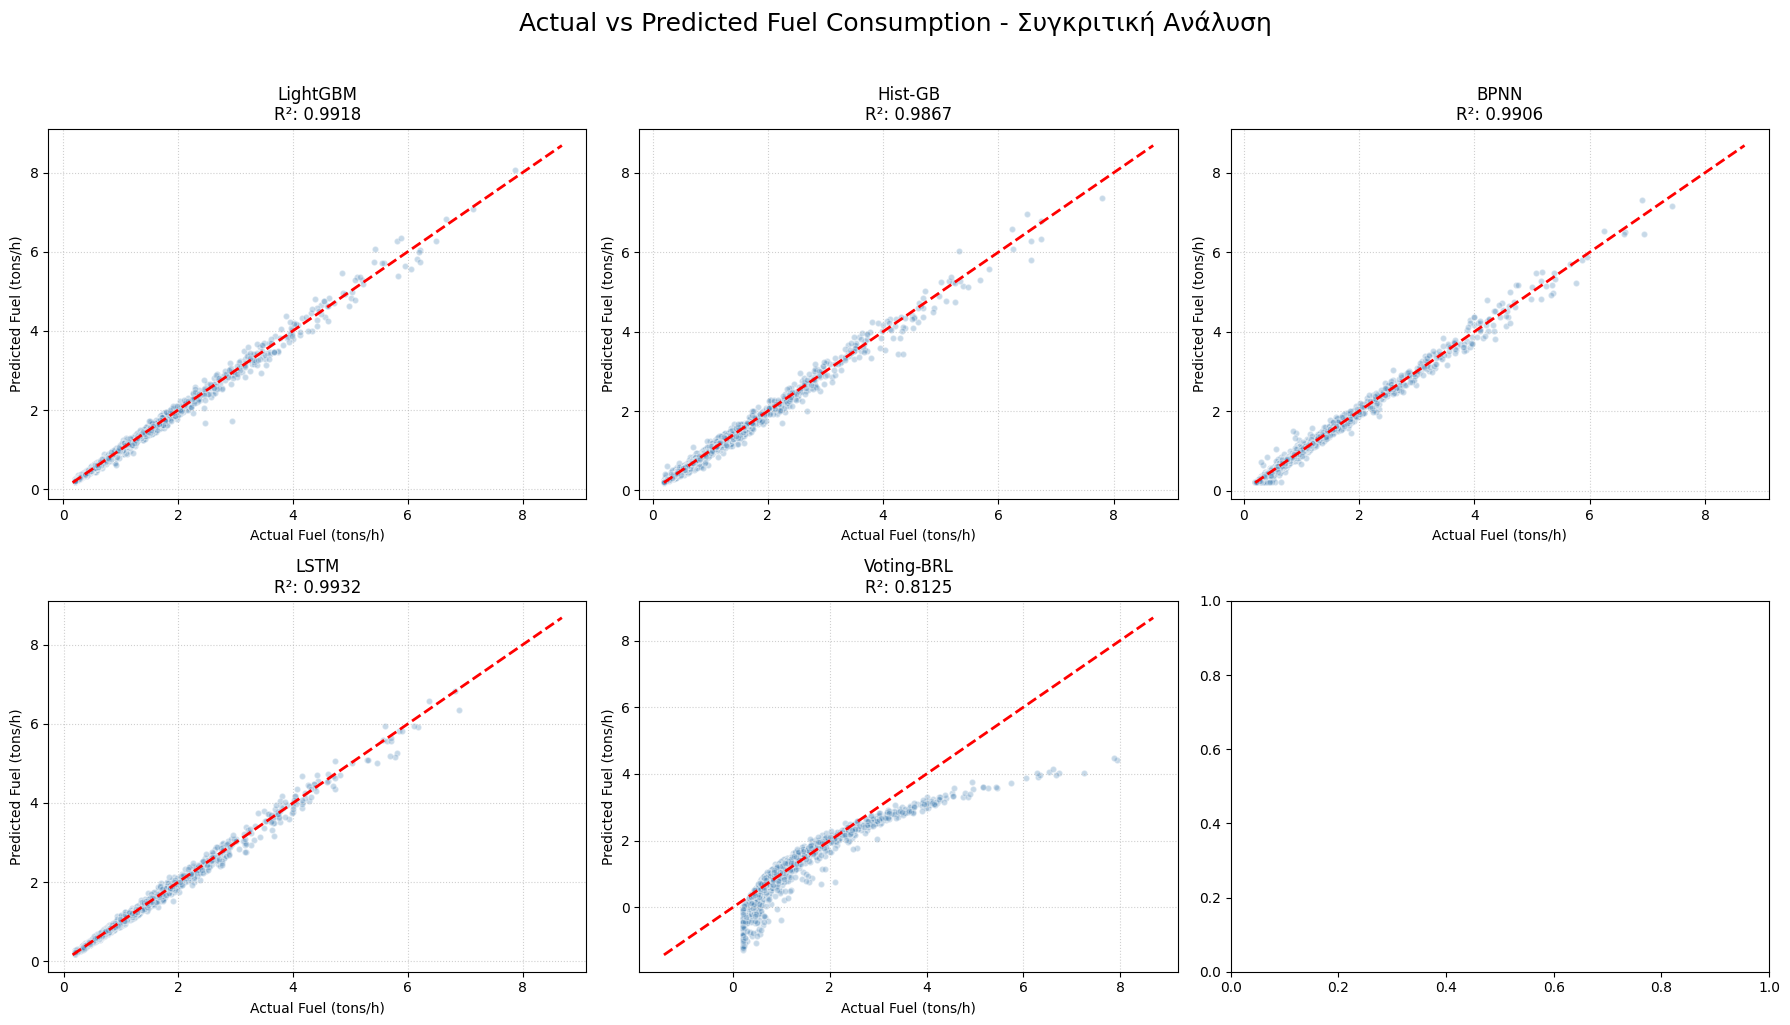

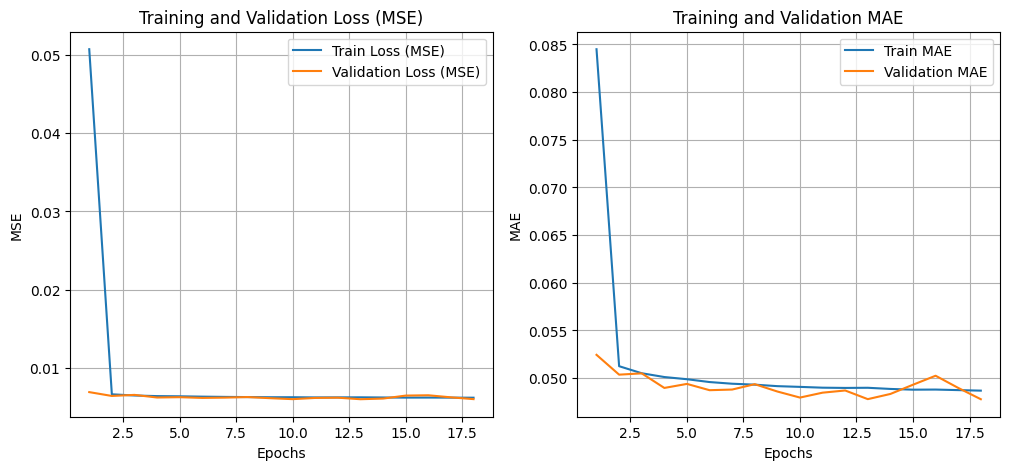

In [4]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, VotingRegressor
from sklearn.linear_model import BayesianRidge, Lasso

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Λεξικό για την αποθήκευση των αποτελεσμάτων
results = {
    'Model': [],
    'R2': [],
    'RMSE': [],
    'MAE': [],
    'Time (s)': []
}

# Λεξικό για να κρατήσουμε τις προβλέψεις για τα Scatter Plots
predictions_dict = {}



# 1. LightGBM
print("Εκπαίδευση LightGBM...")
start_time = time.time()
lgbm = LGBMRegressor(n_estimators=500, max_depth=7, learning_rate=0.05, random_state=42, n_jobs=-1)
lgbm.fit(X_train_scaled, y_train)
y_pred_lgbm = lgbm.predict(X_test_scaled)
t_lgbm = time.time() - start_time

results['Model'].append('LightGBM')
results['R2'].append(r2_score(y_test, y_pred_lgbm))
results['RMSE'].append(np.sqrt(mean_squared_error(y_test, y_pred_lgbm)))
results['MAE'].append(mean_absolute_error(y_test, y_pred_lgbm))
results['Time (s)'].append(t_lgbm)
predictions_dict['LightGBM'] = (y_test.values, y_pred_lgbm)


# 2. Hist-Gradient Boosting
print("Εκπαίδευση Hist-Gradient Boosting...")
start_time = time.time()
hgb = HistGradientBoostingRegressor(max_depth=7, learning_rate=0.05, random_state=42)
hgb.fit(X_train_scaled, y_train)
y_pred_hgb = hgb.predict(X_test_scaled)
t_hgb = time.time() - start_time

results['Model'].append('Hist-GB')
results['R2'].append(r2_score(y_test, y_pred_hgb))
results['RMSE'].append(np.sqrt(mean_squared_error(y_test, y_pred_hgb)))
results['MAE'].append(mean_absolute_error(y_test, y_pred_hgb))
results['Time (s)'].append(t_hgb)
predictions_dict['Hist-GB'] = (y_test.values, y_pred_hgb)


# 3. BPNN (Neural Network)
print(" Εκπαίδευση BPNN (MLP)...")
start_time = time.time()
bpnn = MLPRegressor(hidden_layer_sizes=(7, 7), learning_rate_init=0.01, max_iter=300, random_state=42, early_stopping=True)
bpnn.fit(X_train_scaled, y_train)
y_pred_bpnn = bpnn.predict(X_test_scaled)
t_bpnn = time.time() - start_time

results['Model'].append('BPNN')
results['R2'].append(r2_score(y_test, y_pred_bpnn))
results['RMSE'].append(np.sqrt(mean_squared_error(y_test, y_pred_bpnn)))
results['MAE'].append(mean_absolute_error(y_test, y_pred_bpnn))
results['Time (s)'].append(t_bpnn)
predictions_dict['BPNN'] = (y_test.values, y_pred_bpnn)


# 4. Voting-BRL (Bayesian Ridge + Lasso)
print("Εκπαίδευση Voting-BRL...")
start_time = time.time()
voting_brl = VotingRegressor(estimators=[('bayesian', BayesianRidge(alpha_1=1e-06, alpha_2=1e-06, lambda_1=1e-06, lambda_2=1e-06)), ('lasso', Lasso(alpha=0.1))])
voting_brl.fit(X_train_scaled, y_train)
y_pred_brl = voting_brl.predict(X_test_scaled)
t_brl = time.time() - start_time

results['Model'].append('Voting-BRL')
results['R2'].append(r2_score(y_test, y_pred_brl))
results['RMSE'].append(np.sqrt(mean_squared_error(y_test, y_pred_brl)))
results['MAE'].append(mean_absolute_error(y_test, y_pred_brl))
results['Time (s)'].append(t_brl)
predictions_dict['Voting-BRL'] = (y_test.values, y_pred_brl)

# 5. LSTM (Deep Learning Sequential)
print("Εκπαίδευση LSTM...")
start_time = time.time()

# Αναδιαμόρφωση πινάκων για LSTM (Samples, TimeSteps, Features)
n_features = X_train_scaled.shape[1]
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, n_features))
X_val_lstm = X_val_scaled.reshape((X_val_scaled.shape[0], 1, n_features))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, n_features))

lstm_model = Sequential([
    Input(shape=(1, n_features)),
    LSTM(128, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = lstm_model.fit(X_train_lstm, y_train,validation_data=(X_val_lstm, y_val), epochs=20, batch_size=256, callbacks=[early_stop], verbose=0)

# Τελική πρόβλεψη στο "άγνωστο" Test Set
y_pred_lstm = lstm_model.predict(X_test_lstm, verbose=0).flatten()
t_lstm = time.time() - start_time

results['Model'].append('LSTM')
results['R2'].append(r2_score(y_test, y_pred_lstm))
results['RMSE'].append(np.sqrt(mean_squared_error(y_test, y_pred_lstm)))
results['MAE'].append(mean_absolute_error(y_test, y_pred_lstm))
results['Time (s)'].append(t_lstm)
predictions_dict['LSTM'] = (y_test.values, y_pred_lstm)

# ==========================================
# ΑΠΟΤΕΛΕΣΜΑΤΑ & ΓΡΑΦΗΜΑΤΑ
# ==========================================
df_results = pd.DataFrame(results)
print("\nΠίνακας Συνολικών Αποτελεσμάτων:")
display(df_results.round(4))

# Γράφημα 1: Σύγκριση R-Squared και RMSE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='R2', y='Model', data=df_results.sort_values('R2', ascending=False),ax=axes[0], palette='viridis', hue='Model', legend=False)
axes[0].set_title('Σύγκριση Ακρίβειας (R-Squared)', fontsize=14)
axes[0].set_xlim(0, 1.0)
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

sns.barplot(x='RMSE', y='Model', data=df_results.sort_values('RMSE', ascending=True),ax=axes[1], palette='magma', hue='Model', legend=False)
axes[1].set_title('Σύγκριση Σφάλματος (RMSE) - Μικρότερο είναι Καλύτερο', fontsize=14)
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout(pad=3.0)
plt.show()

# Γράφημα 2: Actual vs Predicted
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Actual vs Predicted Fuel Consumption - Συγκριτική Ανάλυση', fontsize=18, y=1.02)
axes = axes.flatten()

models_list = ['LightGBM', 'Hist-GB', 'BPNN', 'LSTM', 'Voting-BRL']

for i, model_name in enumerate(models_list):
    y_true, y_pred = predictions_dict[model_name]

    # Λήψη τυχαίου δείγματος 2000 σημείων για βέλτιστη απόδοση γραφικών
    plot_idx = np.random.choice(len(y_true), size=min(2000, len(y_true)), replace=False)

    axes[i].scatter(y_true[plot_idx], y_pred[plot_idx], alpha=0.3, color='steelblue', edgecolor='w', s=20)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

    # Σωστή εξαγωγή της τιμής του R2 χρησιμοποιώντας το [0]
    r2_val = df_results[df_results["Model"] == model_name]["R2"].values[0]
    axes[i].set_title(f'{model_name}\nR²: {r2_val:.4f}', fontsize=12)
    axes[i].set_xlabel('Actual Fuel (tons/h)')
    axes[i].set_ylabel('Predicted Fuel (tons/h)')
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Γράφημα 3: LSTM Plot of Train and Validation
epochs = range(1, len(history.history['loss']) + 1)
plt.figure(figsize=(12, 5))

# Plot Loss (MSE)
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['loss'], label='Train Loss (MSE)')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Training and Validation Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

# Plot MAE (Mean Absolute Error)
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['mae'], label='Train MAE')
plt.plot(epochs, history.history['val_mae'], label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.show()